## <font color=blue> 1. Imports

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, gaussian_kde
import numpy as np

## <font color=blue> 2. Carregamento e Preparação do Dataset

In [13]:
# constantes para usar nos gráficos
CORES_ORIGEM = {"JFK": "steelblue", "LGA": "darkorange", "EWR": "seagreen"}
CORES_ATRASO = {"Adiantado": "seagreen", "Pontual": "steelblue", "Atrasado": "tomato"}

### 2.1 Carregamento do dataset

**fonte:** fornecido pelo professor. todos os voos domésticos partindo de Nova York (JFK, LGA, EWR) em 2013

**variáveis:**
- **temporais:** `year`, `month`, `day`, `dep_time`, `arr_time`, `hour`, `minute`
- **atrasos:** `dep_delay`, `arr_delay`, em minutos. negativos = adiantado
- **voo:** `carrier`, `tailnum`, `flight`, `origin`, `dest`
- **operacionais:** `air_time` (minutos em voo), `distance` (milhas)

In [14]:
PATH_NYCFLIGHTS = "/home/heitor/Documentos/projetos/MBA/01_estatistica/01_estatistica-nycflights/nycflights.csv"

flights_df = pd.read_csv(PATH_NYCFLIGHTS)

print(f"flights_df: {flights_df.shape}")
flights_df.info()

flights_df: (32735, 16)
<class 'pandas.DataFrame'>
RangeIndex: 32735 entries, 0 to 32734
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   year       32735 non-null  int64
 1   month      32735 non-null  int64
 2   day        32735 non-null  int64
 3   dep_time   32735 non-null  int64
 4   dep_delay  32735 non-null  int64
 5   arr_time   32735 non-null  int64
 6   arr_delay  32735 non-null  int64
 7   carrier    32735 non-null  str  
 8   tailnum    32735 non-null  str  
 9   flight     32735 non-null  int64
 10  origin     32735 non-null  str  
 11  dest       32735 non-null  str  
 12  air_time   32735 non-null  int64
 13  distance   32735 non-null  int64
 14  hour       32735 non-null  int64
 15  minute     32735 non-null  int64
dtypes: int64(12), str(4)
memory usage: 4.0 MB


### 2.2 Visão geral do dataset

In [15]:
flights_df.head(10)


,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute
0,2013,6,30,940,15,1216,-4,VX,N626VA,407,JFK,LAX,313,2475,9,40
1,2013,5,7,1657,-3,2104,10,DL,N3760C,329,JFK,SJU,216,1598,16,57
2,2013,12,8,859,-1,1238,11,DL,N712TW,422,JFK,LAX,376,2475,8,59
3,2013,5,14,1841,-4,2122,-34,DL,N914DL,2391,JFK,TPA,135,1005,18,41
4,2013,7,21,1102,-3,1230,-8,9E,N823AY,3652,LGA,ORF,50,296,11,2
5,2013,1,1,1817,-3,2008,3,AA,N3AXAA,353,LGA,ORD,138,733,18,17
6,2013,12,9,1259,14,1617,22,WN,N218WN,1428,EWR,HOU,240,1411,12,59
7,2013,8,13,1920,85,2032,71,B6,N284JB,1407,JFK,IAD,48,228,19,20
8,2013,9,26,725,-10,1027,-8,AA,N3FSAA,2279,LGA,MIA,148,1096,7,25
9,2013,4,30,1323,62,1549,60,EV,N12163,4162,EWR,JAX,110,820,13,23


In [16]:
flights_df.head(10).describe()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,flight,air_time,distance,hour,minute
count,10.0,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,2013.0,6.900000,15.900000,1344.300000,15.200000,1614.300000,12.300000,1683.000000,177.400000,1213.700000,13.100000,34.300000
std,0.0,3.478505,10.268073,440.746097,32.186263,424.808728,31.871443,1407.937656,107.997119,790.613552,4.433459,19.927926
min,2013.0,1.000000,1.000000,725.000000,-10.000000,1027.000000,-34.000000,329.000000,48.000000,228.000000,7.000000,2.000000
25%,2013.0,5.000000,8.250000,980.500000,-3.000000,1232.000000,-7.000000,410.750000,116.250000,754.750000,9.500000,20.750000
50%,2013.0,6.500000,13.500000,1291.000000,-2.000000,1583.000000,6.500000,1417.500000,143.000000,1050.500000,12.500000,32.500000
75%,2013.0,8.750000,24.750000,1777.000000,14.750000,2026.000000,19.250000,2363.000000,234.000000,1551.250000,17.500000,53.000000
max,2013.0,12.000000,30.000000,1920.000000,85.000000,2122.000000,71.000000,4162.000000,376.000000,2475.000000,19.000000,59.000000


## <font color=blue> 3. Análise Descritiva

### 3.1 Medidas descritivas

In [17]:
cols = ['dep_delay', 'arr_delay', 'air_time', 'distance']
pd.DataFrame({
    'média': flights_df[cols].mean(),
    'média': flights_df[cols].max(),
    'mediana': flights_df[cols].median(),
    'desvio padrão': flights_df[cols].std(),
    'assimetria': flights_df[cols].apply(skew)
}).round(2)

,média,mediana,desvio padrão,assimetria
dep_delay,1301,-2.0,40.41,5.26
arr_delay,1272,-5.0,44.69,4.02
air_time,686,129.0,93.53,1.07
distance,4983,888.0,733.68,1.10


### 3.2 Distribuição dos atrasos

#### 3.2.1 Densidade

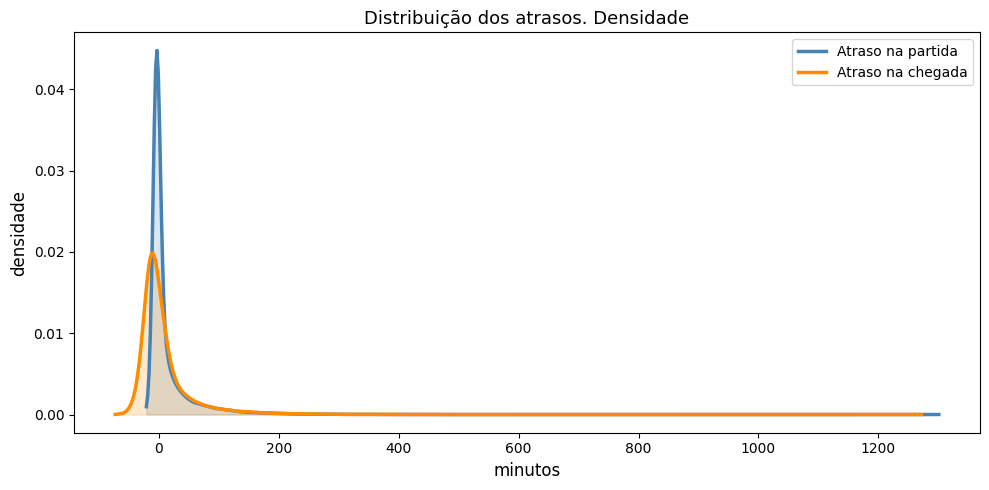

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

cols = ['dep_delay', 'arr_delay']
labels = ['Atraso na partida', 'Atraso na chegada']
cores = ['steelblue', 'darkorange']

for col, label, cor in zip(cols, labels, cores):
    data = flights_df[col].dropna()
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 600)
    ax.plot(x, kde(x), color=cor, linewidth=2.5, label=label)
    ax.fill_between(x, kde(x), alpha=0.2, color=cor)

ax.set_xlabel('minutos', fontsize=12)
ax.set_ylabel('densidade', fontsize=12)
ax.set_title('Distribuição dos atrasos. Densidade', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

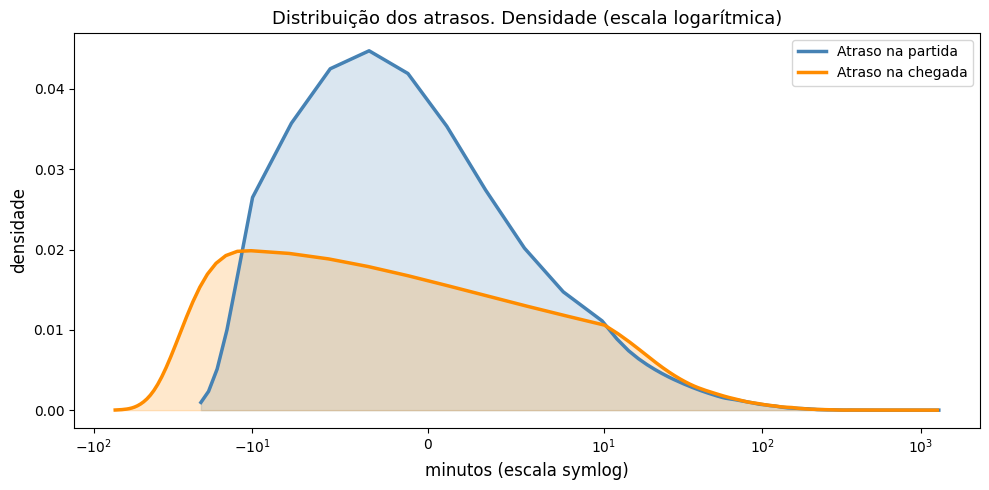

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

cols = ['dep_delay', 'arr_delay']
labels = ['Atraso na partida', 'Atraso na chegada']
cores = ['steelblue', 'darkorange']

for col, label, cor in zip(cols, labels, cores):
    data = flights_df[col].dropna()
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 600)
    ax.plot(x, kde(x), color=cor, linewidth=2.5, label=label)
    ax.fill_between(x, kde(x), alpha=0.2, color=cor)

ax.set_xscale('symlog', linthresh=10)
ax.set_xlabel('minutos (escala symlog)', fontsize=12)
ax.set_ylabel('densidade', fontsize=12)
ax.set_title('Distribuição dos atrasos. Densidade (escala logarítmica)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**observações:**
- ambas as distribuições têm assimetria positiva: a cauda direita é longa, com poucos voos acumulando atrasos acima de 100 minutos
- a mediana é menor que a média nos dois casos, indicando que os grandes atrasos puxam a média para cima
- a maioria dos voos parte e chega próximo ao horário previsto ou adiantada

#### 3.2.2 Boxplot

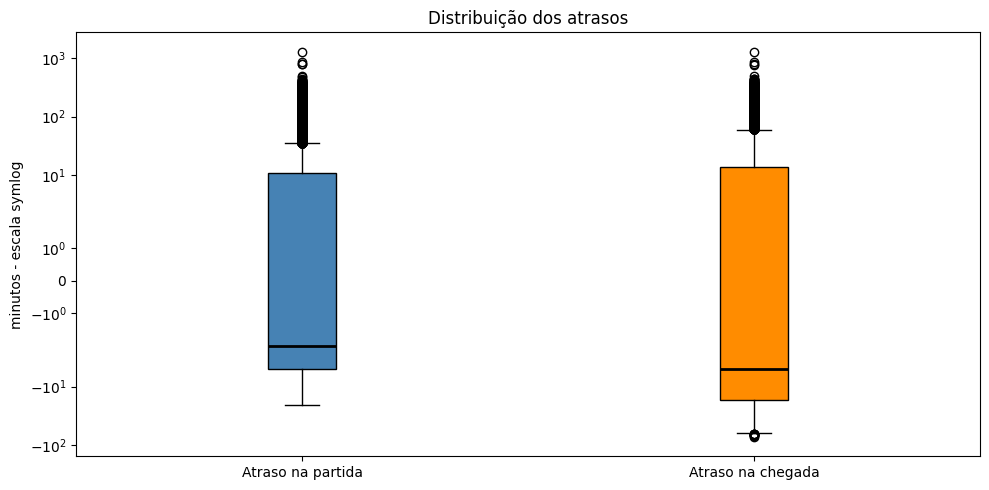

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(
    [flights_df['dep_delay'].dropna(), flights_df['arr_delay'].dropna()],
    tick_labels=['Atraso na partida', 'Atraso na chegada'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
)
for patch, cor in zip(bp['boxes'], ['steelblue', 'darkorange']):
    patch.set_facecolor(cor)

ax.set_yscale('symlog')
ax.set_ylabel('minutos - escala symlog')
ax.set_title('Distribuição dos atrasos')
plt.tight_layout()
plt.show()

**observações:**
- utilizei a escala symlog ao inves da log normal pois existem atrasos negativos. symlog faz o log e depois espelha pro negativo
- os outliers se distanciam do bigode superior em centenas de minutos, confirmando a cauda longa vista no grafico de densidade
- A maioria dos voos tem atrasos pequenos de acordo com o grafico
- o bigode inferior é curto, apesar de muitos voos terem atraso negativo, não há muito espaço para adiantar. ao contrário dos atrasos positivos podem passar de 100min

#### 3.2.3 Categorização dos atrasos

**regra de negócio:**
- **adiantado:** `dep_delay < 0`. partida antes do horário previsto
- **pontual:** `dep_delay = 0`. partida exatamente no horário previsto
- **atrasado:** `dep_delay > 0`. partida após o horário previsto

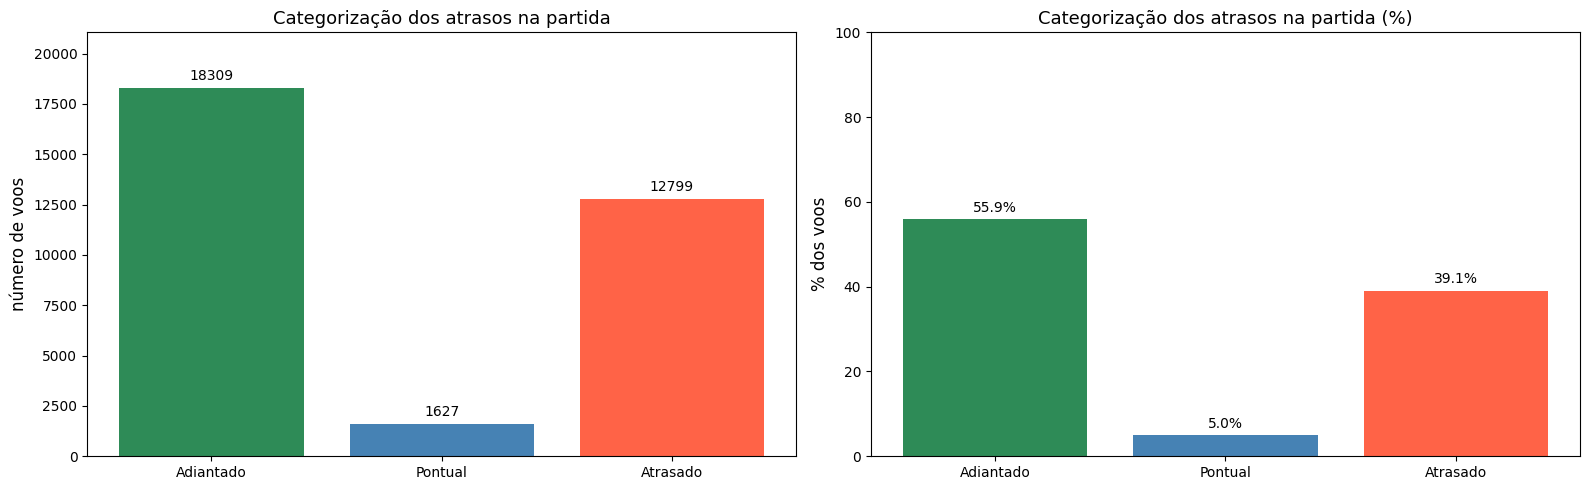

In [21]:
conditions = [flights_df['dep_delay'] < 0, flights_df['dep_delay'] == 0]
choices = ['Adiantado', 'Pontual']
flights_df['status_atraso'] = np.select(conditions, choices, default='Atrasado')

ordem = ['Adiantado', 'Pontual', 'Atrasado']
contagem = flights_df['status_atraso'].value_counts().reindex(ordem)
proporcao = (contagem / len(flights_df) * 100).round(1)
cores = [CORES_ATRASO[s] for s in ordem]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(ordem, contagem.values, color=cores)
axes[0].bar_label(bars, fmt='%d', padding=3, fontsize=10)
axes[0].set_ylabel('número de voos', fontsize=12)
axes[0].set_title('Categorização dos atrasos na partida', fontsize=13)
axes[0].set_ylim(0, contagem.max() * 1.15)

bars2 = axes[1].bar(ordem, proporcao.values, color=cores)
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=10)
axes[1].set_ylabel('% dos voos', fontsize=12)
axes[1].set_title('Categorização dos atrasos na partida (%)', fontsize=13)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

**observações:**
- 55.9% dos voos partem adiantados, 39.1% atrasados e 5.0% pontuais
- apesar da maioria partir adiantada, a média de `dep_delay` é positiva: os atrasos quando ocorrem têm magnitude maior que os adiantamentos
- voos pontuais representam fração pequena: sair exatamente no minuto previsto é raro na operação aérea

### 3.3 Análise por aeroporto de origem

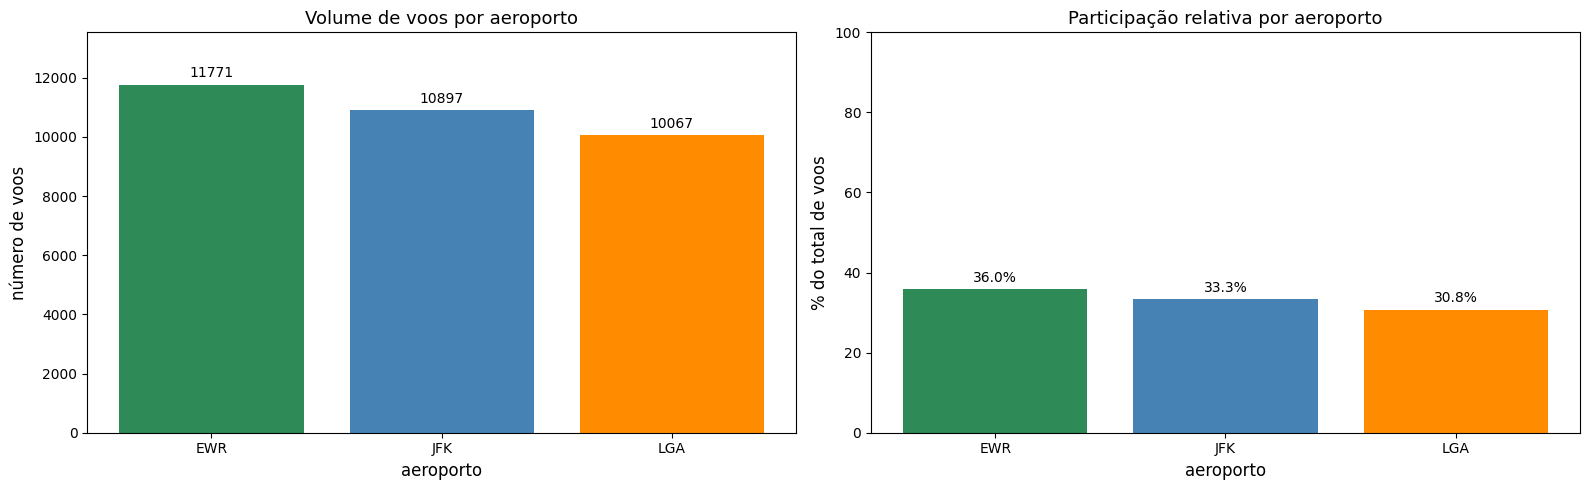

In [22]:
volume = flights_df['origin'].value_counts().sort_values(ascending=False)
volume_pct = (volume / volume.sum() * 100)
cores = [CORES_ORIGEM[o] for o in volume.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(volume.index, volume.values, color=cores)
axes[0].bar_label(bars, fmt='%d', padding=3, fontsize=10)
axes[0].set_xlabel('aeroporto', fontsize=12)
axes[0].set_ylabel('número de voos', fontsize=12)
axes[0].set_title('Volume de voos por aeroporto', fontsize=13)
axes[0].set_ylim(0, volume.max() * 1.15)

bars2 = axes[1].bar(volume_pct.index, volume_pct.values, color=cores)
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=10)
axes[1].set_xlabel('aeroporto', fontsize=12)
axes[1].set_ylabel('% do total de voos', fontsize=12)
axes[1].set_title('Participação relativa por aeroporto', fontsize=13)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

### 3.4 Análise por companhia aérea

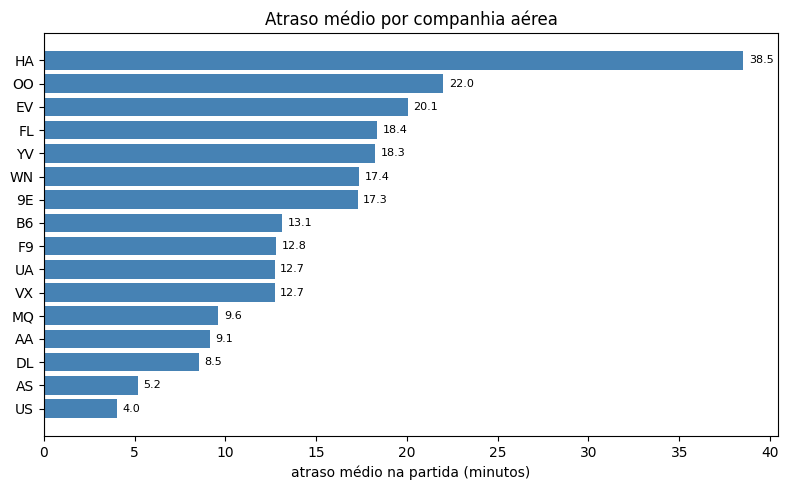

In [23]:
atraso_carrier = (
    flights_df.groupby('carrier')['dep_delay']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'atraso_medio', 'count': 'voos'})
    .sort_values('atraso_medio', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(atraso_carrier.index, atraso_carrier['atraso_medio'], color='steelblue')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('atraso médio na partida (minutos)')
ax.set_title('Atraso médio por companhia aérea')
for i, (idx, row) in enumerate(atraso_carrier.iterrows()):
    ax.text(row['atraso_medio'] + 0.3, i, f"{row['atraso_medio']:.1f}", va='center', fontsize=8)
plt.tight_layout()
plt.show()